In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/online_retail_clean.csv", parse_dates=["InvoiceDate"])

# Nur echte Käufe (keine Stornos) für die Kohortenzuordnung nutzen
kaeufe = df[df["is_cancellation"] == False].copy()

# 1. Kaufmonat jeder Transaktion
kaeufe["InvoiceMonth"] = kaeufe["InvoiceDate"].dt.to_period("M")

# 2. Kohorte = erster Kaufmonat des Kunden
kaeufe["CohortMonth"] = kaeufe.groupby("Customer ID")["InvoiceMonth"].transform("min")

# 3. Wie viele Monate liegen zwischen Kaufmonat und Kohorten-Startmonat?
kaeufe["CohortIndex"] = (
    (kaeufe["InvoiceMonth"].dt.year - kaeufe["CohortMonth"].dt.year) * 12
    + (kaeufe["InvoiceMonth"].dt.month - kaeufe["CohortMonth"].dt.month)
)

# 4. Anzahl eindeutiger aktiver Kunden je Kohorte und Monatsabstand
cohort_data = kaeufe.groupby(["CohortMonth", "CohortIndex"])["Customer ID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="Customer ID")

# 5. In Retention-Prozent umrechnen (bezogen auf Kohortengröße bei Index 0)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

retention.index = retention.index.astype(str)
retention.round(1)

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9,37.7,34.2,33.6,36.2,...,30.3,26.3,30.3,28.3,26.0,25.5,31.5,30.5,40.7,19.7
2010-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8,23.0,27.9,31.9,...,15.1,23.5,19.8,18.5,19.6,24.3,19.3,24.5,5.7,NaN
2010-02,100.0,23.7,22.3,29.0,24.5,19.9,19.1,28.5,25.3,27.4,...,19.9,16.0,16.2,14.4,22.9,22.9,16.2,5.9,NaN,NaN
2010-03,100.0,19.0,23.0,24.2,23.3,20.3,24.6,30.2,27.5,10.8,...,16.9,17.4,15.6,17.6,20.1,21.2,7.9,NaN,NaN,NaN
2010-04,100.0,19.4,19.4,16.3,18.4,22.4,27.6,26.2,10.5,10.9,...,15.6,13.9,15.0,18.0,22.4,5.8,NaN,NaN,NaN,NaN
2010-05,100.0,15.7,16.9,17.3,17.7,25.6,21.3,12.6,5.9,8.3,...,12.6,13.8,16.5,15.4,4.7,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.4,18.9,20.4,23.0,28.5,12.6,8.9,8.1,11.9,...,12.2,13.3,20.4,5.2,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.6,18.3,29.6,29.0,14.0,11.3,14.5,14.5,11.3,...,17.2,23.7,8.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.4,29.6,32.1,17.3,11.7,9.9,12.3,13.6,13.0,...,19.8,6.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


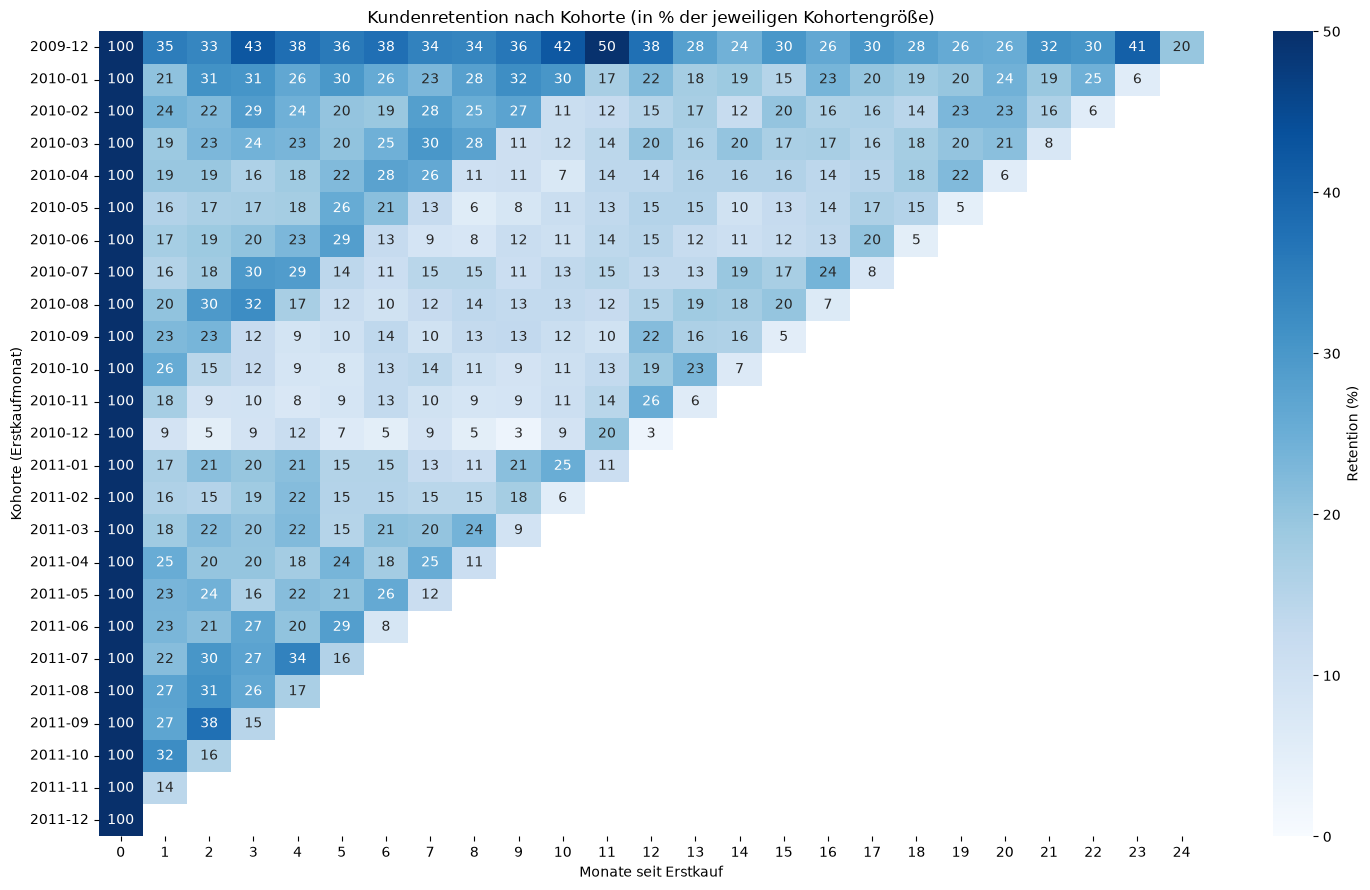

In [2]:
plt.figure(figsize=(15, 9))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=50, cbar_kws={"label": "Retention (%)"})
plt.title("Kundenretention nach Kohorte (in % der jeweiligen Kohortengröße)")
plt.xlabel("Monate seit Erstkauf")
plt.ylabel("Kohorte (Erstkaufmonat)")
plt.tight_layout()
plt.show()

In [3]:
retention.to_csv("../data/processed/cohort_retention.csv")
print("Gespeichert:", retention.shape)

Gespeichert: (25, 25)
